In [57]:
# Download the dataset
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

--2025-07-09 12:56:51--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv.4’

titanic.csv.4       100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2025-07-09 12:56:51 (4.26 MB/s) - ‘titanic.csv.4’ saved [60302/60302]



# Predicting survival in the Titanic disaster using decision trees

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score , recall_score,precision_score, f1_score,confusion_matrix

In [59]:
np.random.seed(86)

data=pd.read_csv('titanic.csv')
print(data.head(),'\n')
print(data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S   



According to the results of the data.info function, the Age, Cabin, and Embarked columns have missing data, and the Name, Sex, Ticket, Cabin, and Embarked columns have categorical data.
We will remove the Cabin column because it has a lot of missing data. To replace the missing values ​​in the Age column, we can divide people into several groups based on their gender and ticket class, and consider the median age of each group as the age of the missing data for that group. For example, men who traveled on this ship were older than women because most of them were traveling for business or, for example, people who had 1st class tickets were wealthier and usually older, and people who had 3rd class tickets were younger and had less financial power. To fill in the missing data in the Embarked column, we can use the mode and see at which port most of the passengers boarded the ship.

In [60]:
# Handle missing values
data.drop('Cabin', axis=1, inplace=True)
data['Age'].fillna(data.groupby(['Sex', 'Pclass'])['Age'].transform('median'), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


/tmp/ipython-input-60-2839458572.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data.groupby(['Sex', 'Pclass'])['Age'].transform('median'), inplace=True)
/tmp/ipython-input-60-2839458572.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [61]:
# Convert categorical columns to numerical columns
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
data=pd.get_dummies(data, columns=['Embarked'])

# Drop irrelevant features from output & output
y=data['Survived']
X=data.drop(['Survived','Name','Ticket','PassengerId'],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked_C   891 non-null    bool   
 11  Embarked_Q   891 non-null    bool   
 12  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(6), object(2)
memory usage: 72.3+ KB


In [62]:
# Split data into train and test sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=86)

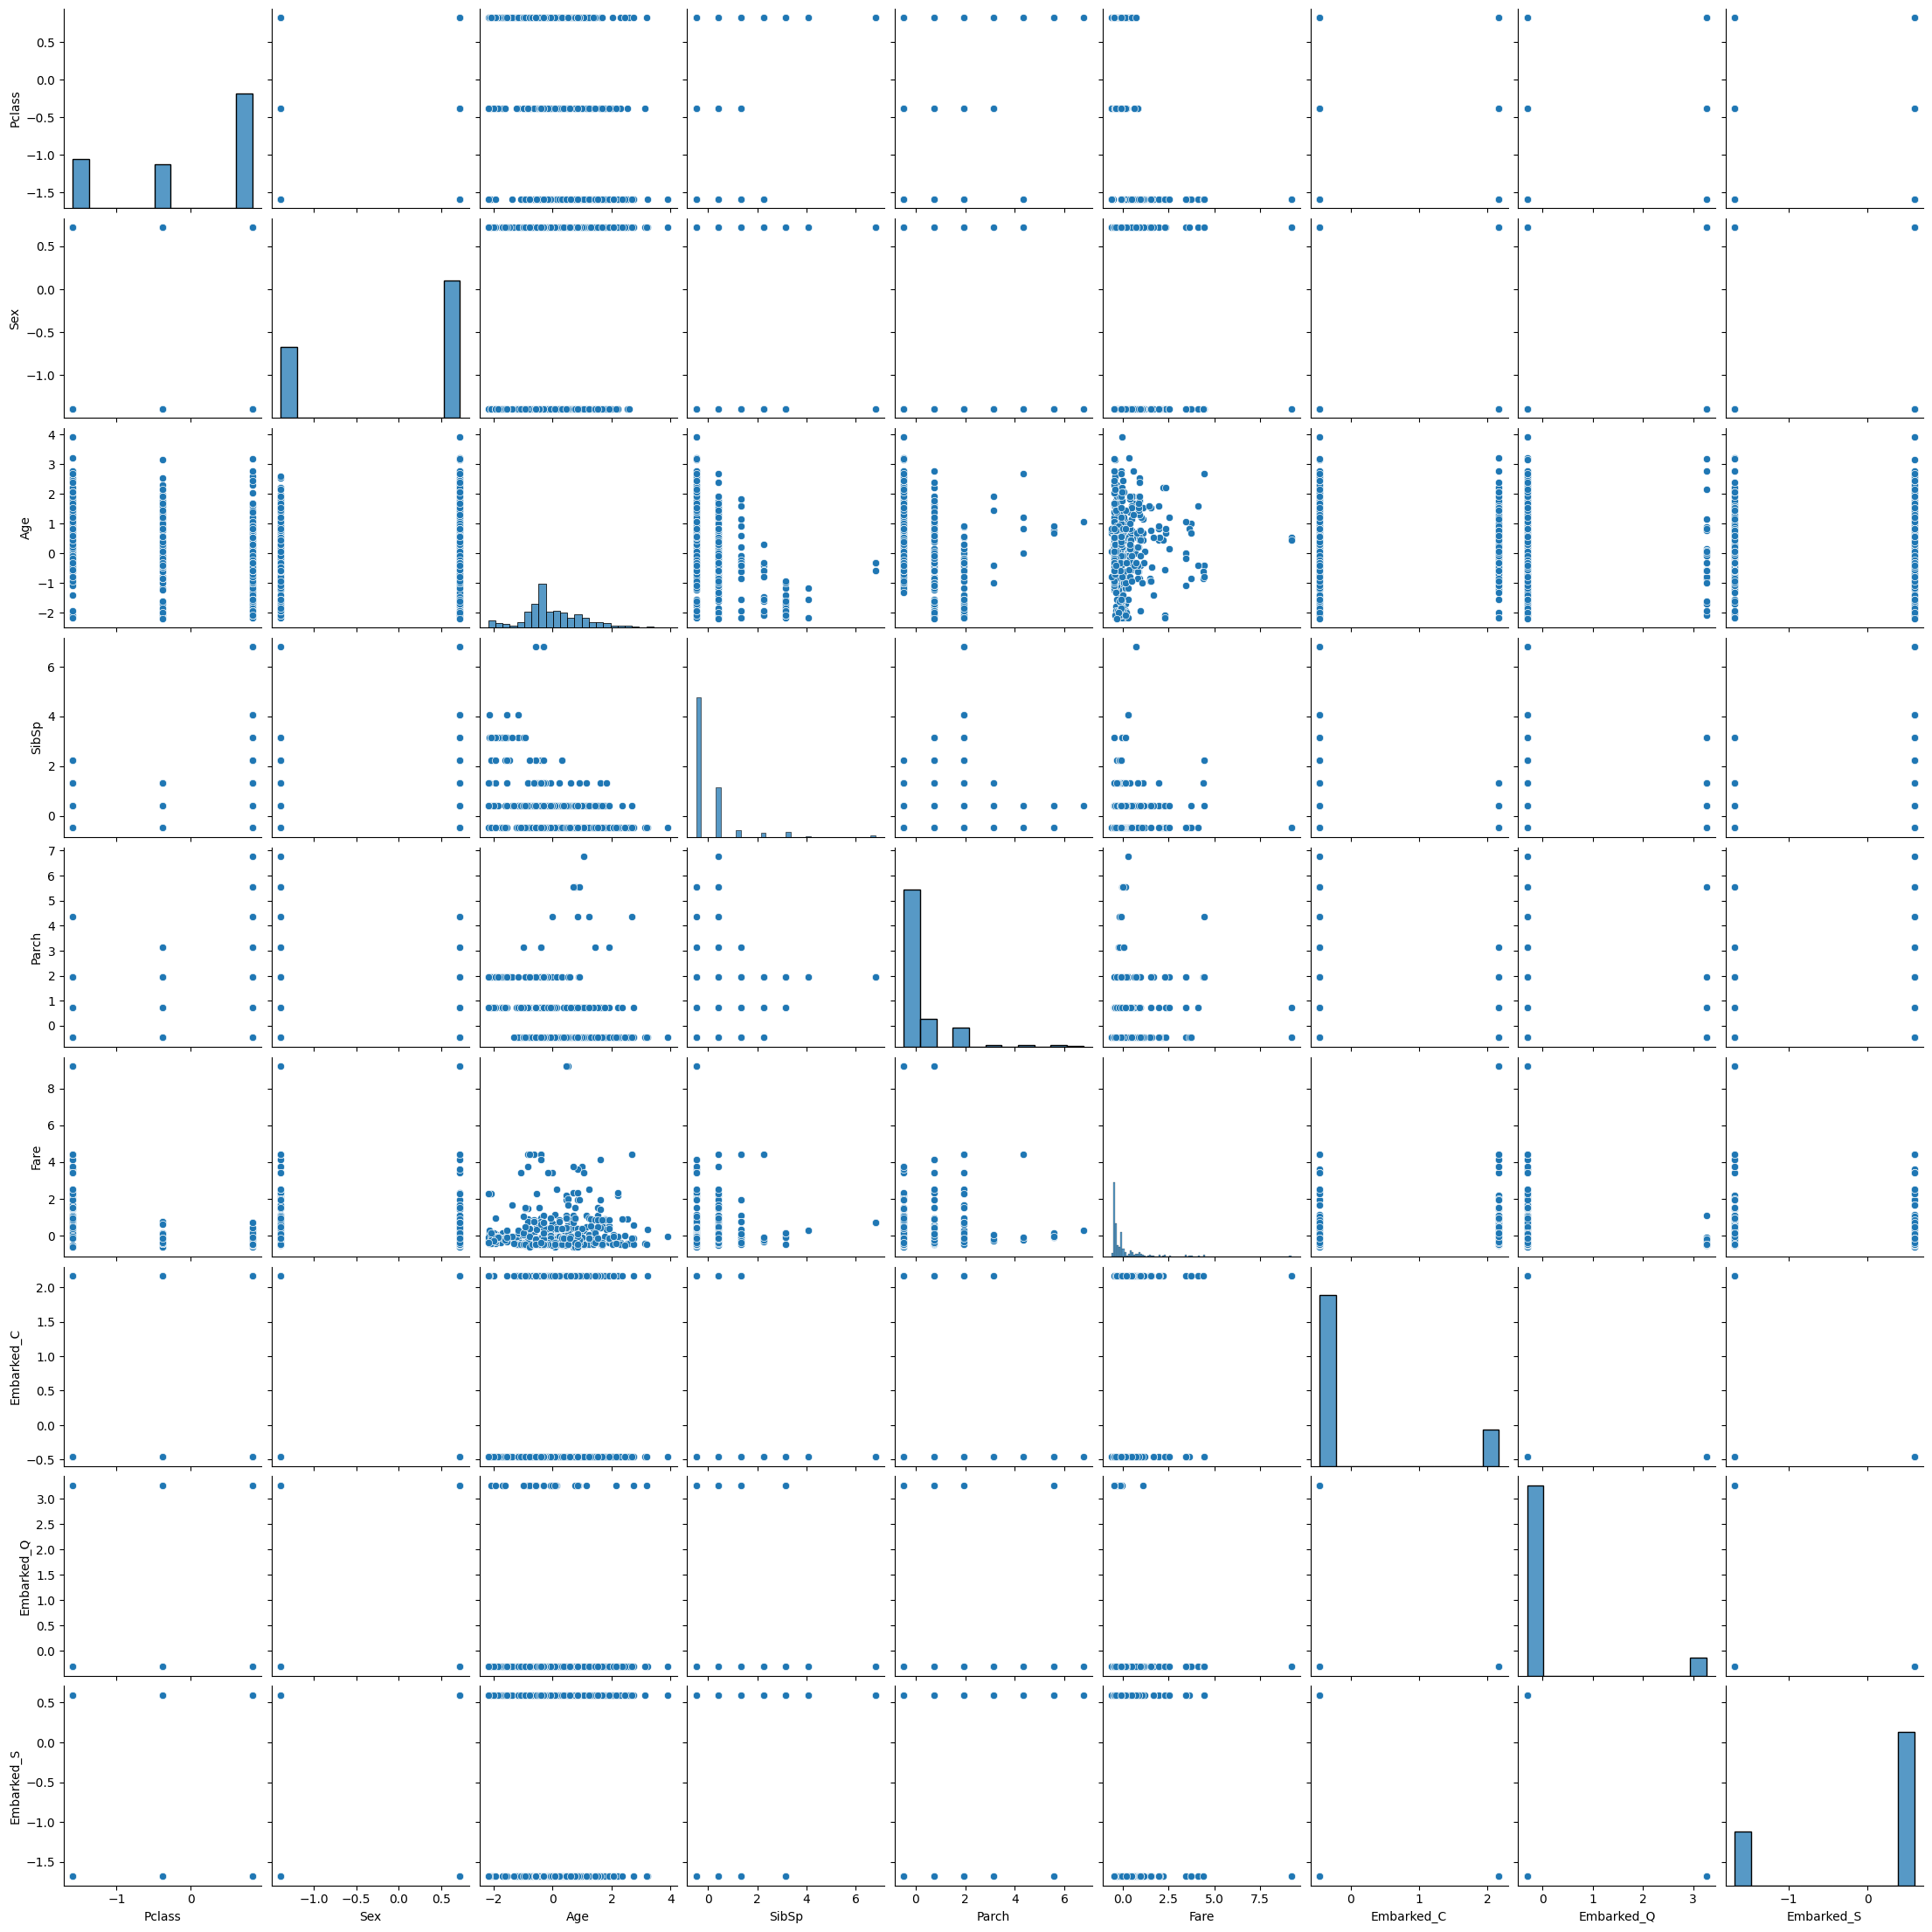

In [63]:
# Normalize data
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Plot nomalized data
X_train_df=pd.DataFrame(X_train,columns=X.columns)
sns.pairplot(X_train_df)
plt.show()


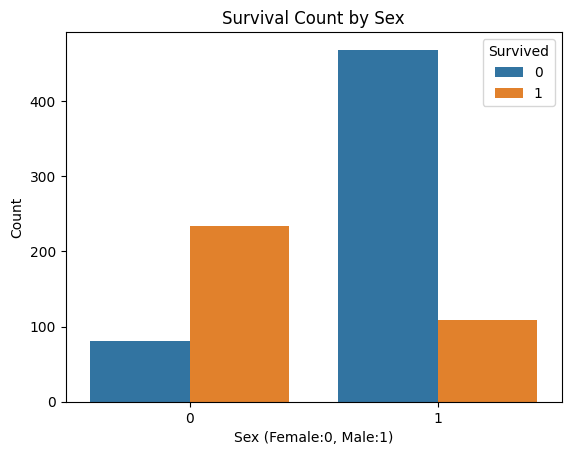

In [64]:
# Plot survival count by sex
sns.countplot(x='Sex',hue='Survived',data=data)
plt.xlabel('Sex (Female:0, Male:1)')
plt.ylabel('Count')
plt.title('Survival Count by Sex')
plt.show()


According to the chart above, most of the men on the ship died and most of the women survived.

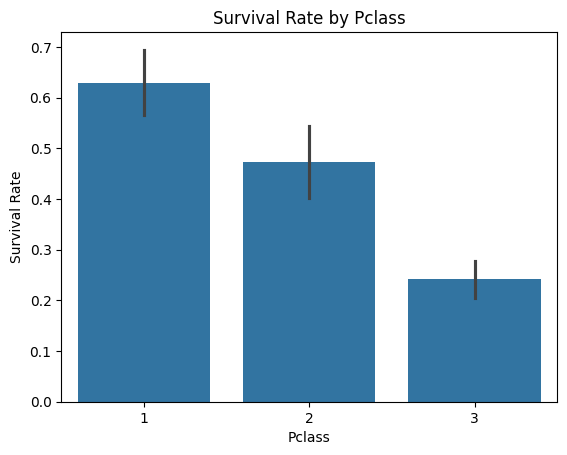

In [65]:
# Plot survival rate by Pclass
sns.barplot(x='Pclass',y='Survived',data=data)
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Pclass')
plt.show()

According to the chart above, the survival rate of 1st class passengers was higher than that of 2nd and 3rd class.

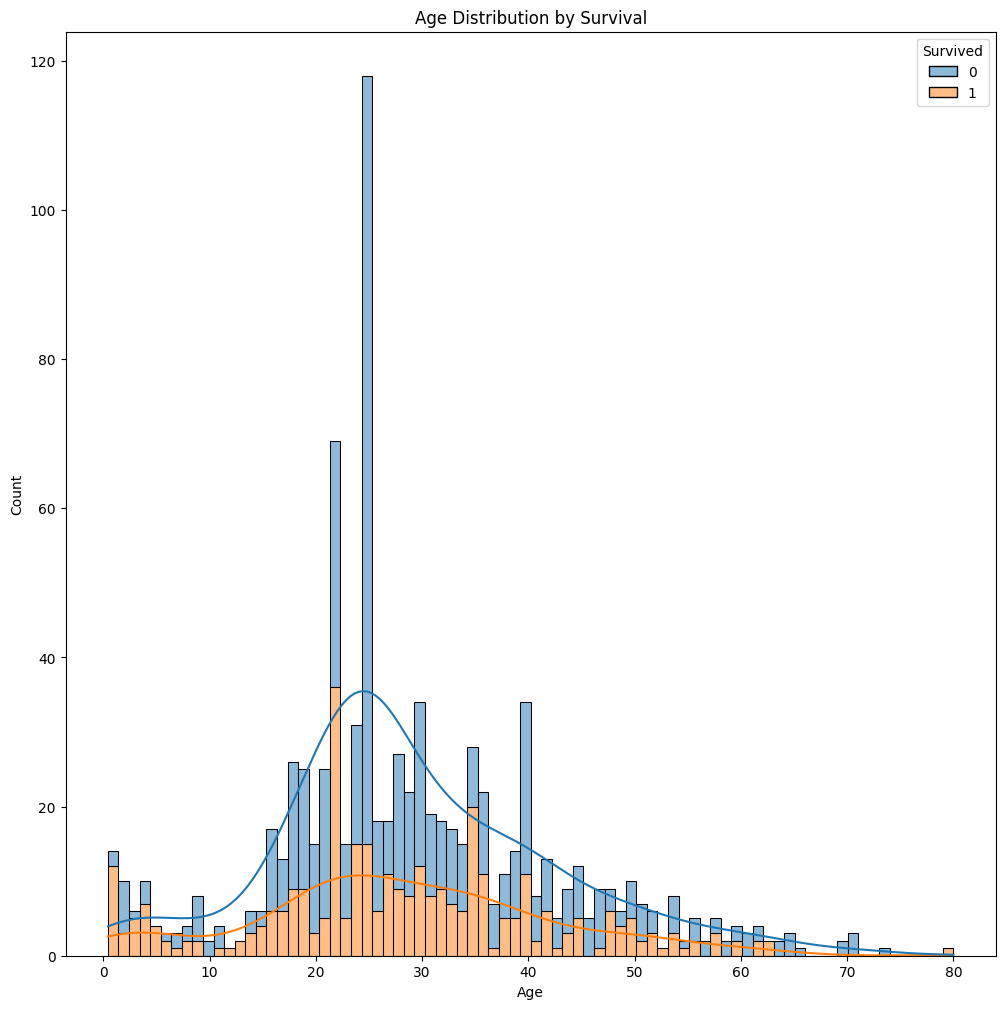

In [75]:
# Plot age distribution by survival
plt.figure(figsize=(12,12))
sns.histplot(data=data,x='Age',hue='Survived',kde=True,multiple='stack',bins=80)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival')
plt.show()

According to the histogram above, children are more likely to survive than die, but at older ages, most people die.

In [67]:
temp=data['Survived'].value_counts()
print(temp)

Survived
0    549
1    342
Name: count, dtype: int64


Given the above numbers, the dataset is not balanced.

In [68]:
# Train a decision tree & optimize max_depth with grid search
dt=DecisionTreeClassifier(random_state=86)
param_grid={'max_depth':range(1,15)}
grid_search=GridSearchCV(dt,param_grid,cv=5,scoring='roc_auc')
grid_search.fit(X_train,y_train)
best_dt=grid_search.best_estimator_
print('Best max_depth:',grid_search.best_params_)
print('Best score:',grid_search.best_score_)



Best max_depth: {'max_depth': 3}
Best score: 0.8462503631466956


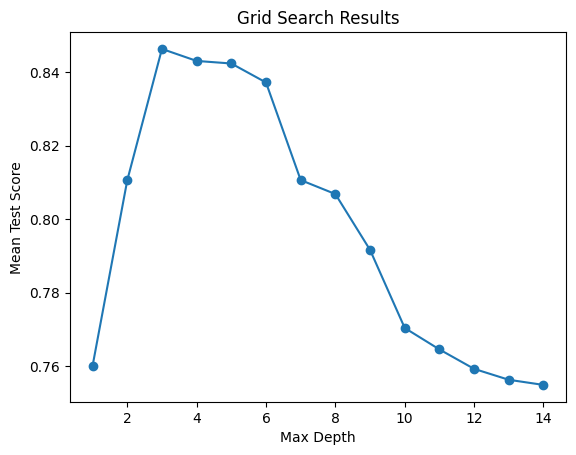

In [69]:
results=pd.DataFrame(grid_search.cv_results_)
plt.plot(results['param_max_depth'],results['mean_test_score'],marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score')
plt.title('Grid Search Results')
plt.show()

      feature  importance
1         Sex    0.620342
0      Pclass    0.256705
2         Age    0.078290
5        Fare    0.044663
3       SibSp    0.000000
4       Parch    0.000000
6  Embarked_C    0.000000
7  Embarked_Q    0.000000
8  Embarked_S    0.000000


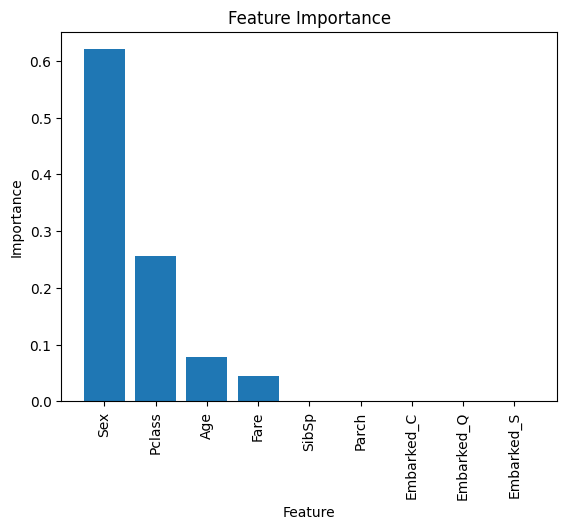

In [70]:
feature_importances=best_dt.feature_importances_
feature_names=X.columns
df=pd.DataFrame({'feature':feature_names,'importance':feature_importances})
df=df.sort_values('importance',ascending=False)
print(df)
plt.bar(df['feature'],df['importance'])
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

I tried different scoring methods like accuracy, f1-score and roc-auc to find the best tree depth with grid search and roc-auc gave the best results. It should be noted that the data is a bit unbalanced and the percentage of the two classes is not 50:50. According to roc-auc, the best tree depth was 3 and the most effective and important feature was the gender of the individuals, followed by their ticket class and then their age and other features were not significantly important.

Accuracy:0.8212290502793296
Precision:0.8208955223880597
Recall:0.7333333333333333
F1 Score:0.7746478873239436


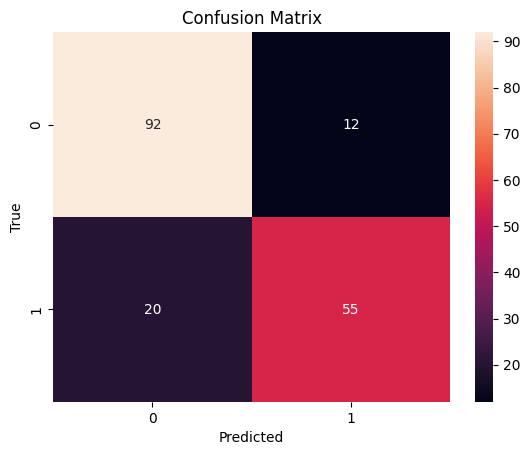

In [71]:
y_pred=best_dt.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy:{accuracy}')
precision=precision_score(y_test,y_pred)
print(f'Precision:{precision}')
recall=recall_score(y_test,y_pred)
print(f'Recall:{recall}')
f1=f1_score(y_test,y_pred)
print(f'F1 Score:{f1}')

cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

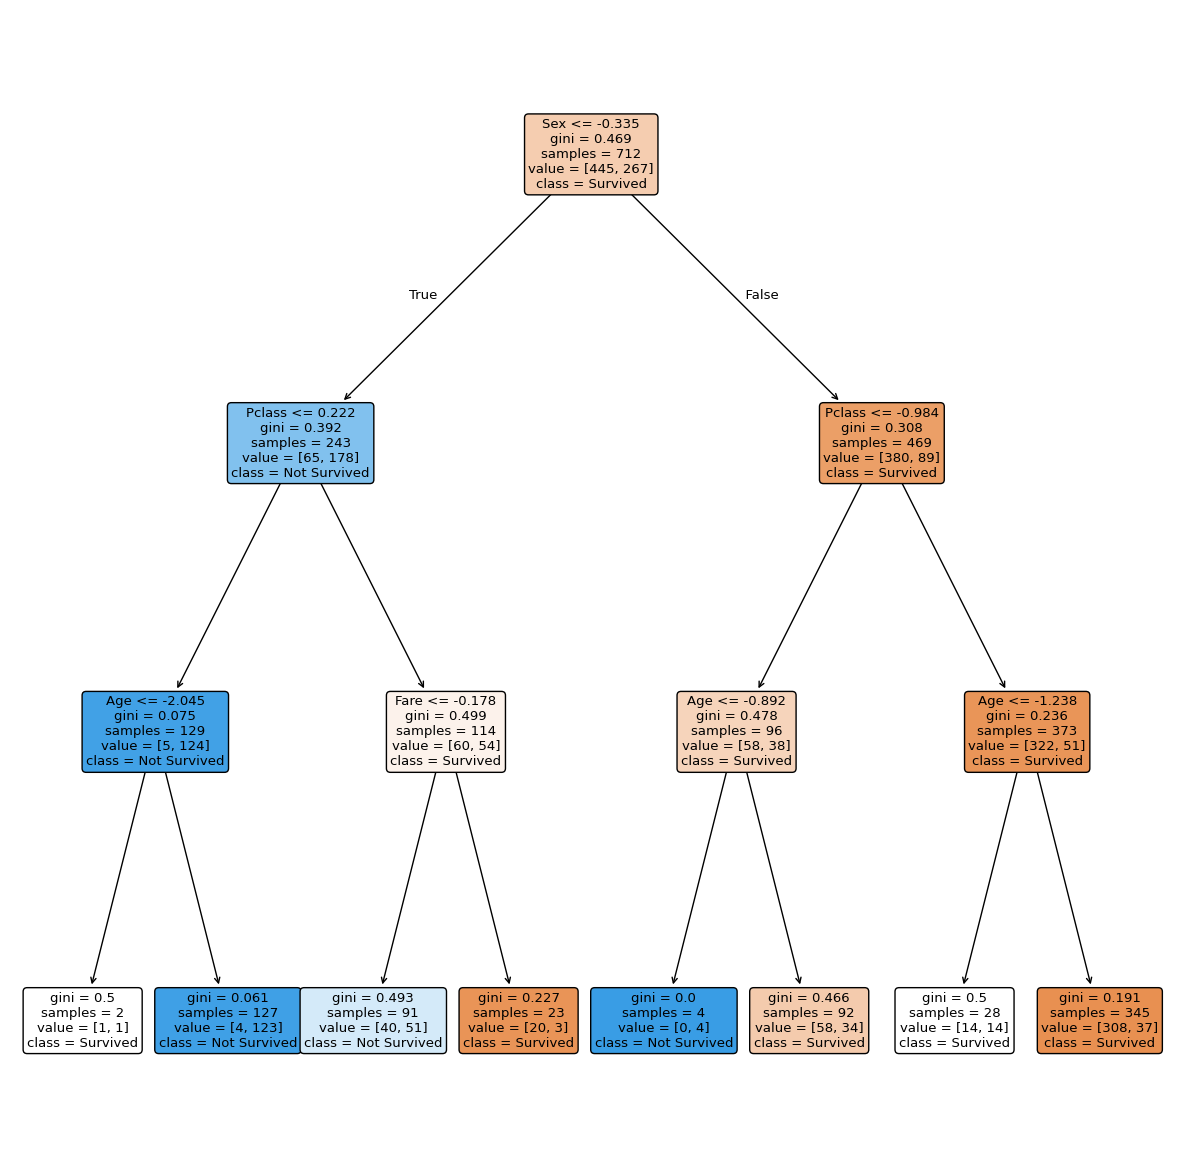

In [72]:
plt.figure(figsize=(15,15))
plot_tree(best_dt,filled=True,rounded=True,feature_names=X.columns,class_names=['Survived','Not Survived'])
plt.show()

Given the drawn tree, the fact that each node has two children, and the fact that the Gini index has been calculated, the CART algorithm was used to construct the tree.